In [37]:
from pathlib import Path
import shutil
import subprocess
import sys
import zipfile
import os


import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown


# =========================
# CONFIGURAZIONE PATH PROGETTO
# =========================

PROJECT_NAME = "MammoDiffusion"

# Lascia None se esegui il notebook dalla repo o dalla cartella notebooks/.
# Su Colab/Drive puoi impostare ad esempio:
# PROJECT_ROOT_OVERRIDE = "/content/drive/MyDrive/MammoDiffusion"
PROJECT_ROOT_OVERRIDE = None


def find_project_root(project_name=PROJECT_NAME, override=PROJECT_ROOT_OVERRIDE):
    """Trova automaticamente la root del progetto MammoDiffusion."""
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not root.exists():
            raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE non esiste: {root}")
        return root

    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if candidate.name == project_name:
            return candidate
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    for candidate in [
        cwd / project_name,
        Path("/content") / project_name,
        Path("/content/drive/MyDrive") / project_name,
        Path.home() / project_name,
        Path.home() / "Progetto" / project_name,
    ]:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Non riesco a trovare la root del progetto MammoDiffusion.\n"
        "Esegui il notebook dalla repo clonata oppure imposta PROJECT_ROOT_OVERRIDE."
    )


PROJECT_ROOT = find_project_root()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "data"
DATA_ORIGINAL_DIR = DATA_DIR / "original"
DATA_PROCESSED_DIR = DATA_DIR / "processed"
DATA_AUG = DATA_DIR / "real_augmented"
TRAIN_DIR = DATA_PROCESSED_DIR / "train" / "1"
ARCHIVES_DIR = DATA_DIR / "archives"

for directory in [DATA_ORIGINAL_DIR, DATA_PROCESSED_DIR, DATA_AUG]:
    directory.mkdir(parents=True, exist_ok=True)


# DATASET PREPROCESSATO

# Il file Drive si chiama processed.zip e deve contenere direttamente:
# train/0/, train/1/, val/0/, val/1/, test/0/, test/1/ e metadata/*.csv.
# Dopo l'estrazione il risultato atteso è:
# MammoDiffusion/data/processed/train/0/*.png
# MammoDiffusion/data/processed/train/1/*.png
# MammoDiffusion/data/processed/val/0/*.png
# MammoDiffusion/data/processed/val/1/*.png
# MammoDiffusion/data/processed/test/0/*.png
# MammoDiffusion/data/processed/test/1/*.png
# MammoDiffusion/data/processed/metadata/*.csv
PROCESSED_DRIVE_ID = "16qdV3arYBeMK7nLZpm3dwGV4lzTLVYmo"
PROCESSED_ZIP_PATH = ARCHIVES_DIR / "processed.zip"
PROCESSED_DIR = DATA_PROCESSED_DIR

# True = riscarica processed.zip e riestrae tutto, cancellando data/processed/.
# False = se train/val/test con sottocartelle 0/1 sono già presenti, non scarica nulla.
FORCE_REDOWNLOAD = False

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("PROCESSED_ZIP_PATH:", PROCESSED_ZIP_PATH)

PROJECT_ROOT: D:\Progetto Deep\MammoDiffusion
PROCESSED_DIR: D:\Progetto Deep\MammoDiffusion\data\processed
PROCESSED_ZIP_PATH: D:\Progetto Deep\MammoDiffusion\data\archives\processed.zip


In [38]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
EXPECTED_SPLITS = ["train", "val", "test"]
EXPECTED_LABELS = ["0", "1"]
REQUIRED_METADATA = ["all_processed.csv", "train.csv", "val.csv", "test.csv"]


def count_images(folder):
    """Conta le immagini dentro una cartella, includendo eventuali sottocartelle."""
    folder = Path(folder)
    if not folder.is_dir():
        return 0

    return sum(
        1
        for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def get_split_label_counts(processed_dir):
    """Conta immagini in data/processed/<split>/<label>/, quindi train/0, train/1, ecc."""
    processed_dir = Path(processed_dir).resolve()

    rows = []
    for split in EXPECTED_SPLITS:
        for label in EXPECTED_LABELS:
            rows.append({
                "split": split,
                "label": int(label),
                "folder": str(processed_dir / split / label),
                "n_images": count_images(processed_dir / split / label),
            })

    return pd.DataFrame(rows)


def processed_dataset_ready(processed_dir):
    """
    True se data/processed contiene la struttura corretta:
        train/0, train/1, val/0, val/1, test/0, test/1
    e ciascuna cartella contiene almeno una immagine.
    """
    processed_dir = Path(processed_dir).resolve()
    if not processed_dir.exists():
        return False

    counts_df = get_split_label_counts(processed_dir)
    ready = (counts_df["n_images"] > 0).all()

    if not ready and any((processed_dir / split).exists() for split in EXPECTED_SPLITS):
        print("Dataset preprocessato trovato, ma struttura incompleta:")
        print(counts_df[["split", "label", "n_images"]].to_string(index=False))

    return bool(ready)


def metadata_complete(processed_dir):
    """True se data/processed/metadata contiene tutti i CSV attesi."""
    metadata_dir = Path(processed_dir) / "metadata"
    return all((metadata_dir / name).exists() for name in REQUIRED_METADATA)


def parse_filename_metadata(image_path):
    """
    Ricava i metadata minimi dal nome file creato dal preprocessing:
    patient_id_image_id_laterality_view.png
    """
    parts = Path(image_path).stem.split("_")

    patient_id = parts[0] if len(parts) >= 1 else Path(image_path).stem
    image_id = parts[1] if len(parts) >= 2 else Path(image_path).stem
    laterality = parts[2] if len(parts) >= 3 else "unknown"
    view = parts[3] if len(parts) >= 4 else "unknown"

    return patient_id, image_id, laterality, view


def rebuild_metadata_from_folders(processed_dir):
    """Ricostruisce i CSV metadata se mancano, usando train/val/test/0-1/file.png."""
    processed_dir = Path(processed_dir).resolve()
    metadata_dir = processed_dir / "metadata"
    metadata_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    for split in EXPECTED_SPLITS:
        for label_name in EXPECTED_LABELS:
            label_dir = processed_dir / split / label_name
            label = int(label_name)

            for image_path in sorted(label_dir.rglob("*")):
                if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                    continue

                patient_id, image_id, laterality, view = parse_filename_metadata(image_path)

                rows.append({
                    "patient_id": str(patient_id),
                    "image_id": str(image_id),
                    "laterality": str(laterality),
                    "view": str(view),
                    "label": label,
                    "cancer": label,
                    "patient_label": label,
                    "split": split,
                    "source": "real",
                    "original_path": "",
                    "processed_path": str(image_path),
                })

    if not rows:
        raise FileNotFoundError(f"Nessuna immagine valida trovata in {processed_dir}")

    df = pd.DataFrame(rows).sort_values(
        ["split", "label", "patient_id", "image_id"]
    ).reset_index(drop=True)

    df.to_csv(metadata_dir / "all_processed.csv", index=False)

    for split in EXPECTED_SPLITS:
        df[df["split"] == split].reset_index(drop=True).to_csv(
            metadata_dir / f"{split}.csv",
            index=False,
        )

    print("Metadata CSV ricostruiti in:", metadata_dir)
    print(pd.crosstab(df["split"], df["label"]))


def ensure_metadata(processed_dir):
    if metadata_complete(processed_dir):
        print("Metadata CSV già presenti:", Path(processed_dir) / "metadata")
        return

    print("Metadata CSV mancanti o incompleti: li ricostruisco da train/val/test/0-1.")
    rebuild_metadata_from_folders(processed_dir)


def download_processed_zip():
    if PROCESSED_ZIP_PATH.exists() and not FORCE_REDOWNLOAD:
        if zipfile.is_zipfile(PROCESSED_ZIP_PATH):
            print("Archivio già presente, salto download:", PROCESSED_ZIP_PATH)
            return
        print("Archivio presente ma non valido: lo riscarico.")
        PROCESSED_ZIP_PATH.unlink()

    elif PROCESSED_ZIP_PATH.exists():
        PROCESSED_ZIP_PATH.unlink()

    print("Download di processed.zip da Google Drive...")
    gdown.download(
        id=PROCESSED_DRIVE_ID,
        output=str(PROCESSED_ZIP_PATH),
        quiet=False,
    )

    if not PROCESSED_ZIP_PATH.exists() or PROCESSED_ZIP_PATH.stat().st_size == 0:
        raise RuntimeError(
            "Download fallito. Controlla che il file Drive sia condiviso con "
            "'Chiunque abbia il link'."
        )

    if not zipfile.is_zipfile(PROCESSED_ZIP_PATH):
        raise RuntimeError(f"Il file scaricato non sembra uno ZIP valido: {PROCESSED_ZIP_PATH}")

    print("Download completato:", PROCESSED_ZIP_PATH)


def clear_processed_dir():
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

    for item in PROCESSED_DIR.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()


def extract_processed_zip():
    print("Estrazione di processed.zip dentro:", PROCESSED_DIR)
    clear_processed_dir()

    with zipfile.ZipFile(PROCESSED_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(PROCESSED_DIR)


def prepare_processed_dataset():
    """
    Usa data/processed se è già pronta.
    Altrimenti scarica processed.zip e lo estrae direttamente in data/processed/.
    """
    if processed_dataset_ready(PROCESSED_DIR) and not FORCE_REDOWNLOAD:
        print("Dataset preprocessato già presente: salto download ed estrazione.")
        ensure_metadata(PROCESSED_DIR)
        return PROCESSED_DIR.resolve()
    
    PROCESSED_ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
    
    download_processed_zip()
    extract_processed_zip()

    if not processed_dataset_ready(PROCESSED_DIR):
        counts_df = get_split_label_counts(PROCESSED_DIR)
        print(counts_df[["split", "label", "folder", "n_images"]].to_string(index=False))
        raise FileNotFoundError(
            "processed.zip è stato estratto, ma la struttura non è quella attesa.\n"
            "Lo ZIP deve contenere direttamente train/0, train/1, val/0, val/1, "
            "test/0, test/1 e metadata/*.csv."
        )

    ensure_metadata(PROCESSED_DIR)

    print("Dataset preprocessato pronto.")
    print("DATASET_ROOT:", PROCESSED_DIR.resolve())
    print("\nConteggio immagini:")
    print(get_split_label_counts(PROCESSED_DIR)[["split", "label", "n_images"]].to_string(index=False))

    return PROCESSED_DIR.resolve()


DATASET_ROOT = prepare_processed_dataset()

METADATA_DIR = DATASET_ROOT / "metadata"
ALL_CSV_PATH = METADATA_DIR / "all_processed.csv"
TRAIN_CSV_PATH = METADATA_DIR / "train.csv"
VAL_CSV_PATH = METADATA_DIR / "val.csv"
TEST_CSV_PATH = METADATA_DIR / "test.csv"

print("\nCSV metadata:")
print("ALL_CSV_PATH:", ALL_CSV_PATH)
print("TRAIN_CSV_PATH:", TRAIN_CSV_PATH)
print("VAL_CSV_PATH:", VAL_CSV_PATH)
print("TEST_CSV_PATH:", TEST_CSV_PATH)

Dataset preprocessato già presente: salto download ed estrazione.
Metadata CSV già presenti: D:\Progetto Deep\MammoDiffusion\data\processed\metadata

CSV metadata:
ALL_CSV_PATH: D:\Progetto Deep\MammoDiffusion\data\processed\metadata\all_processed.csv
TRAIN_CSV_PATH: D:\Progetto Deep\MammoDiffusion\data\processed\metadata\train.csv
VAL_CSV_PATH: D:\Progetto Deep\MammoDiffusion\data\processed\metadata\val.csv
TEST_CSV_PATH: D:\Progetto Deep\MammoDiffusion\data\processed\metadata\test.csv


In [39]:
def load_metadata(csv_path, dataset_root):
    df = pd.read_csv(csv_path).copy()

    required_cols = ["patient_id", "image_id", "label", "split", "processed_path"]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"Mancano colonne obbligatorie in {csv_path}: {missing_cols}")

    df["patient_id"] = df["patient_id"].astype(str)
    df["image_id"] = df["image_id"].astype(str)
    df["label"] = df["label"].astype(int)
    df["split"] = df["split"].astype(str)

    # I vecchi processed_path sono stati creati su Windows.
    # Su Ubuntu Path(...).name non separa correttamente i backslash.
    # Quindi normalizziamo prima i separatori.
    df["filename"] = df["processed_path"].apply(
        lambda p: str(p).replace("\\", "/").split("/")[-1]
    )

    # Ricostruiamo il path locale corretto usando la struttura reale dell'archivio
    df["processed_path"] = df.apply(
        lambda row: str(
            dataset_root / row["split"] / str(row["label"]) / row["filename"]
        ),
        axis=1
    )

    df["file_exists"] = df["processed_path"].apply(lambda p: Path(p).exists())

    missing_files = df[~df["file_exists"]]

    if len(missing_files) > 0:
        print(f"Attenzione: {len(missing_files)} immagini non trovate.")
        display(missing_files[["patient_id", "image_id", "split", "label", "filename", "processed_path"]].head(10))

        print("\nEsempi di path ricostruiti non trovati:")
        for p in missing_files["processed_path"].head(10):
            print(p)

        raise FileNotFoundError("Alcune immagini preprocessate non sono state trovate.")

    df = df.drop(columns=["file_exists"])

    return df

In [40]:
processed_df = load_metadata(ALL_CSV_PATH, DATASET_ROOT)
train_df = load_metadata(TRAIN_CSV_PATH, DATASET_ROOT)
val_df = load_metadata(VAL_CSV_PATH, DATASET_ROOT)
test_df = load_metadata(TEST_CSV_PATH, DATASET_ROOT)

print("Dataset caricato correttamente.")
print("Totale:", len(processed_df))
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nDistribuzione split/label:")
print(pd.crosstab(processed_df["split"], processed_df["label"]))

display(processed_df.head())

Dataset caricato correttamente.
Totale: 2916
Train: 2041
Val: 437
Test: 438

Distribuzione split/label:
label     0    1
split           
test    365   73
train  1701  340
val     364   73


,patient_id,image_id,laterality,view,label,cancer,patient_label,split,source,original_path,processed_path,visual_side_before,visual_side_after,left_ratio_before,right_ratio_before,flipped_by_visual_rule,normalized_tissue_side,normalized_laterality,filename
0,8248,1228024526,L,MLO,1,1,1,train,real,/home/fede/Progetto/MammoDiffusion/data/origin...,D:\Progetto Deep\MammoDiffusion\data\processed...,left,left,0.855382,0.144618,False,left,L,8248_1228024526_L_MLO.png
1,32984,1893902734,L,MLO,0,0,0,train,real,/home/fede/Progetto/MammoDiffusion/data/origin...,D:\Progetto Deep\MammoDiffusion\data\processed...,right,left,0.158146,0.841854,True,left,L,32984_1893902734_L_MLO.png
2,37629,1196209769,R,MLO,0,0,0,train,real,/home/fede/Progetto/MammoDiffusion/data/origin...,D:\Progetto Deep\MammoDiffusion\data\processed...,right,left,0.004466,0.995534,True,left,L,37629_1196209769_R_MLO.png
3,54728,189177296,R,MLO,0,0,0,train,real,/home/fede/Progetto/MammoDiffusion/data/origin...,D:\Progetto Deep\MammoDiffusion\data\processed...,right,left,0.002680,0.997320,True,left,L,54728_189177296_R_MLO.png
4,31287,1630385647,L,MLO,0,0,0,train,real,/home/fede/Progetto/MammoDiffusion/data/origin...,D:\Progetto Deep\MammoDiffusion\data\processed...,left,left,0.799693,0.200307,False,left,L,31287_1630385647_L_MLO.png


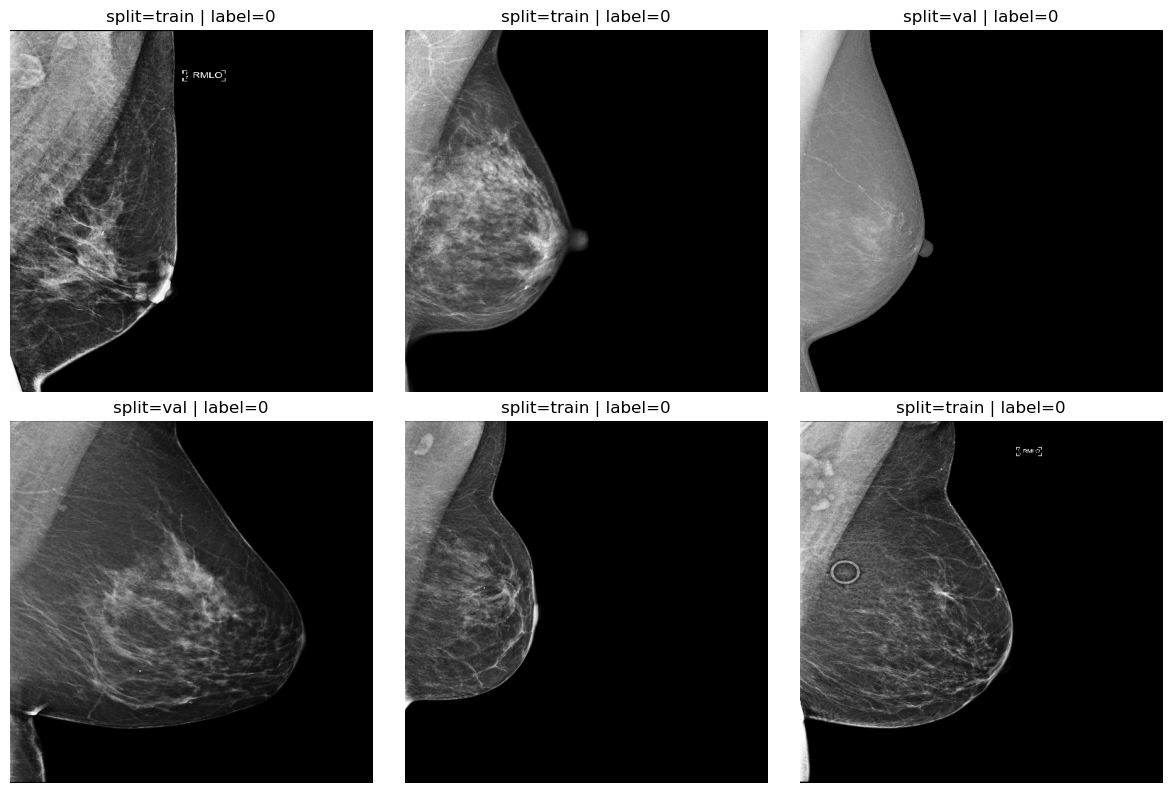

26660_960889337_R_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train
65493_880741065_L_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train
2671_657202909_R_MLO.png | mode: L | size: (512, 512) | label: 0 | split: val
62351_183239079_L_MLO.png | mode: L | size: (512, 512) | label: 0 | split: val
61080_1474548138_L_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train
55043_1224521855_R_MLO.png | mode: L | size: (512, 512) | label: 0 | split: train


In [41]:
sample_df = processed_df.sample(min(6, len(processed_df)), random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    img = Image.open(row["processed_path"]).convert("L")

    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(f'split={row["split"]} | label={row["label"]}')
    plt.axis("off")

plt.tight_layout()
plt.show()

for _, row in sample_df.iterrows():
    img = Image.open(row["processed_path"])
    print(
        Path(row["processed_path"]).name,
        "| mode:", img.mode,
        "| size:", img.size,
        "| label:", row["label"],
        "| split:", row["split"]
    )

In [42]:
# Creazione del dataset di training per il diffusore

# Quante copie augmentate creare per ogni immagine positiva.
# 0 = nessuna augmentation positiva.
# 1 = ogni positivo ha 1 copia augmentata.
# 2 = ogni positivo ha 2 copie augmentate, ecc.
POSITIVE_AUGMENT_COPIES = 3

# Se True, cancella e ricrea la cartella SD_TRAIN_DIR.
RESET_DATASET = True

if RESET_DATASET and DATA_AUG.exists():
    shutil.rmtree(DATA_AUG)
    
DATA_AUG.mkdir(parents=True, exist_ok=True)

# Usiamo SOLO train_df, perché val/test devono restare reali e non contaminati.
source_df = train_df.copy().reset_index(drop=True)

required_cols = ["patient_id", "image_id", "label", "split", "processed_path"]
missing_cols = [col for col in required_cols if col not in source_df.columns]

if missing_cols:
    raise ValueError(f"Mancano colonne obbligatorie in train_df: {missing_cols}")

print("Distribuzione train originale:")
print(source_df["label"].value_counts())


def mild_positive_augmentation(img, aug_idx):
    """
    Augmentation leggera per mammografie positive.
    Non fa flip, perché il preprocessing ha già normalizzato il tessuto verso sinistra.
    Applica solo piccole variazioni di contrasto/luminosità/rumore.
    """
    arr = np.array(img).astype(np.float32)

    rng = np.random.default_rng(42 + aug_idx)

    # Piccola variazione contrasto
    contrast = rng.uniform(0.90, 1.10)

    # Piccola variazione luminosità
    brightness = rng.uniform(-8, 8)

    # Rumore molto leggero
    noise = rng.normal(loc=0.0, scale=2.0, size=arr.shape)

    mean = arr.mean()
    arr = (arr - mean) * contrast + mean
    arr = arr + brightness + noise

    arr = np.clip(arr, 0, 255).astype(np.uint8)

    return Image.fromarray(arr, mode="L")


metadata_rows = []
out_idx = 0

for row_idx, row in source_df.iterrows():
    label = int(row["label"])
    src_path = Path(row["processed_path"])

    if not src_path.exists():
        raise FileNotFoundError(f"Immagine non trovata: {src_path}")

    # Carico e salvo in grayscale
    img_l = Image.open(src_path).convert("L")
    
    out_name = f"mammo_{out_idx:06d}_label{label}.png"
    out_path = DATA_AUG / out_name
    img_l.save(out_path)

    metadata_rows.append({
        "file_name": out_name,
        "label": label,
        "patient_id": str(row["patient_id"]),
        "image_id": str(row["image_id"]),
        "source": "real",
        "original_processed_path": str(src_path)
    })

    out_idx += 1

    # Augmentation SOLO per classe positiva
    if label == 1 and POSITIVE_AUGMENT_COPIES > 0:
        for aug_num in range(POSITIVE_AUGMENT_COPIES):
            aug_img_l = mild_positive_augmentation(
                img_l,
                aug_idx=(row_idx * 100 + aug_num)
            )

            aug_name = f"mammo_{out_idx:06d}_label1_aug{aug_num}.png"
            aug_path = DATA_AUG / aug_name
            aug_img_l.save(aug_path)

            metadata_rows.append({
                "file_name": aug_name,
                "label": 1,
                "patient_id": str(row["patient_id"]),
                "image_id": str(row["image_id"]),
                "source": "positive_augmentation",
                "original_processed_path": str(src_path)
            })

            out_idx += 1


metadata_sd_df = pd.DataFrame(metadata_rows)
metadata_csv_path = DATA_AUG / "metadata.csv"
metadata_sd_df.to_csv(metadata_csv_path, index=False)

print("Dataset per Stable Diffusion creato.")
print("Cartella:", DATA_AUG)
print("metadata.csv:", metadata_csv_path)
print("\nDistribuzione label nel dataset SD:")
print(metadata_sd_df["label"].value_counts())
print("\nDistribuzione source:")
print(metadata_sd_df["source"].value_counts())

display(metadata_sd_df.head())

Distribuzione train originale:
label
0    1701
1     340
Name: count, dtype: int64
Dataset per Stable Diffusion creato.
Cartella: D:\Progetto Deep\MammoDiffusion\data\real_augmented
metadata.csv: D:\Progetto Deep\MammoDiffusion\data\real_augmented\metadata.csv

Distribuzione label nel dataset SD:
label
0    1701
1    1360
Name: count, dtype: int64

Distribuzione source:
source
real                     2041
positive_augmentation    1020
Name: count, dtype: int64


,file_name,label,patient_id,image_id,source,original_processed_path
0,mammo_000000_label1.png,1,8248,1228024526,real,D:\Progetto Deep\MammoDiffusion\data\processed...
1,mammo_000001_label1_aug0.png,1,8248,1228024526,positive_augmentation,D:\Progetto Deep\MammoDiffusion\data\processed...
2,mammo_000002_label1_aug1.png,1,8248,1228024526,positive_augmentation,D:\Progetto Deep\MammoDiffusion\data\processed...
3,mammo_000003_label1_aug2.png,1,8248,1228024526,positive_augmentation,D:\Progetto Deep\MammoDiffusion\data\processed...
4,mammo_000004_label0.png,0,32984,1893902734,real,D:\Progetto Deep\MammoDiffusion\data\processed...
